In [1]:
import os, glob, sys, time
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.extend([parent_dir])

from moleculenet_helpers import *
from LatentKernCP.utils import *

### Load and preprocess dataset

In [2]:
# =========================
# Config (tiny & consistent)
# =========================
SEED       = 214
N_SUBSET   = 2000                
BATCH_SIZE = 32
EPOCHS     = 50
PATIENCE   = 10
HIDDEN     = 64
TARGET_IDX = 2                 
LR         = 1e-3
WD         = 1e-5
K = 7

OUTDIR = os.path.join(parent_dir,"ESOL_outputs_all")
PATTERN = "esol_fixed_pca_outputs_*.npz"

set_seed(SEED)

# ---------- load all runs ----------
files = sorted(glob.glob(os.path.join(OUTDIR, PATTERN)))
runs = []
for f in files:
    d = np.load(f, allow_pickle=True)
    runs.append({
    "Ztest_pca":       d["Ztest_pca"],
    # --- SpeedCP ---
    "covers_speedcp": d["lakcp_cv_covers"].astype(int),
    "cutoffs_speedcp":d["lakcp_cv_cutoffs"],
    "time_speedcp":   float(d["lakcp_cv_time"]),
     # --- Split-CP ---
    "covers_scp":      d["scp_covers"].astype(int),
    "cutoffs_scp":     float(d["scp_cutoffs"]),   # scalar stored as array
    "time_scp":        float(d["scp_time"]),
    # --- PCP ---
    "covers_pcp":      d["pcp_covers"].astype(int),
    "cutoffs_pcp":     d["pcp_cutoffs"],
    "time_pcp":        float(d["pcp_time"]),
    # --- RLCP ---
    "covers_rlcp":     d["rlcp_covers"].astype(int),
    "cutoffs_rlcp":    d["rlcp_cutoffs"],
    "time_rlcp":       float(d["rlcp_time"]),
    # --- CondCP ---
    "covers_cc":       d["condconf_covers"].astype(int),
    "cutoffs_cc":      d["condconf_cutoffs"],
    "time_cc":         float(d["condconf_time"]),
})
print(f"Loaded {len(runs)} runs")


Loaded 50 runs


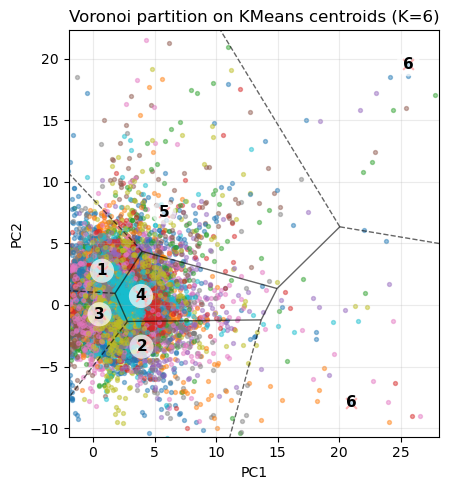

In [3]:
# ---------- 1) Fit ONE KMeans on all runs (2D PCA) ----------
Ztest_all = np.vstack([r["Ztest_pca"] for r in runs])  
X2 = Ztest_all[:, :2]                                   
km = KMeans(n_clusters=K, random_state=SEED, n_init="auto")
km.fit(X2)
centroids = km.cluster_centers_

# ---------- 2) Build Voronoi on centroids ----------
vor = Voronoi(centroids)

# ---------- 3) Assign labels to each point by nearest centroid (Voronoi partition) ----------
for r in runs:
    Zt2 = r["Ztest_pca"][:, :2]
    r["labels_voronoi"] = cdist(Zt2, centroids).argmin(axis=1)  # int labels in [0..K-1]

# ---------- 4) Plot (points, Voronoi edges, centroids) ----------
fig, ax = plt.subplots(figsize=(6, 5))
for i, r in enumerate(runs):
    pts = r["Ztest_pca"][:, :2]
    ax.scatter(pts[:,0], pts[:,1], s=8, alpha=0.45)

# Voronoi edges (draw AFTER points; set limits afterwards so they don't auto-rescale)
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='k', line_alpha=0.6)

# centroids + numeric labels
ax.scatter(centroids[:,0], centroids[:,1], c='red', s=60, marker='x', label='Centroids')
for j, (x, y) in enumerate(centroids):
    map = {0:1, 1:2, 2:3, 5:4, 4:5, 3:6, 6:6}
    j = map[j]
    ax.text(x, y, str(j), fontsize=11, fontweight='bold',
            ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='circle'))

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Voronoi partition on KMeans centroids (K=6)")

# (optional) pick a rectangle to zoom on; set AFTER voronoi_plot_2d (it resets limits)
#ax.set_xlim(-10, 70)
#ax.set_ylim(-20, 20)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [4]:
# remap labels
map = {0:1, 1:2, 2:3, 5:4, 4:5, 3:6, 6:6}
for r in runs:
    lab = r["labels_voronoi"]
    new_lab = np.vectorize(map.get)(lab)
    r["labels_voronoi_merged"] = new_lab.astype(int)

In [5]:

METHODS = {
    "SpeedCP":   {"cover_key": "covers_speedcp", "cut_key": "cutoffs_speedcp", "time_key": "time_speedcp"},
    "CondCP":   {"cover_key": "covers_cc",       "cut_key": "cutoffs_cc",       "time_key": "time_cc"},
    "SplitCP":    {"cover_key": "covers_scp",      "cut_key": "cutoffs_scp",      "time_key": "time_scp"},
    "PCP":        {"cover_key": "covers_pcp",      "cut_key": "cutoffs_pcp",      "time_key": "time_pcp"},
    "RLCP":       {"cover_key": "covers_rlcp",     "cut_key": "cutoffs_rlcp",     "time_key": "time_rlcp"},

    }

# Initialize containers: method -> list (len K) of lists (values per run)
cover_by_cluster = {m: [list() for _ in range(1,K)] for m in METHODS}
cut_by_cluster   = {m: [list() for _ in range(1,K)] for m in METHODS}
time_by_cluster  = {m: [list() for _ in range(1,K)] for m in METHODS}
sizes_by_cluster = [list() for _ in range(1,K)]

for r in runs:
    lab = r["labels_voronoi_merged"]
    for c in range(K-1):
        idx = (lab == c+1)
        sizes_by_cluster[c].append(int(idx.sum()))
        if not idx.any():
            continue

        for method, keys in METHODS.items():
            # coverage (per-point 0/1)
            cov = r.get(keys["cover_key"])
            if cov is not None:
                cov = np.asarray(cov, dtype=float)
                cover_by_cluster[method][c].append(float(np.nanmean(cov[idx])))

            # cutoffs (scalar per run OR per-point)
            cuts = r.get(keys["cut_key"])
            if cuts is not None:
                cuts = np.asarray(cuts, dtype=float)
                if cuts.ndim == 0:
                    cut_val = float(cuts)               # scalar cutoff
                else:
                    cut_val = float(np.nanmean(cuts[idx]))  # mean within cluster
                cut_by_cluster[method][c].append(cut_val)

            # time (scalar per run)
            t = r.get(keys["time_key"])
            if t is not None:
                time_by_cluster[method][c].append(float(t))

In [6]:

def summarize_by_cluster(cover_by_cluster, cut_by_cluster, time_by_cluster, methods, K):
    rows = []
    for method in methods:
        for c in range(K-1):
            cover_vals = np.array(cover_by_cluster[method][c], dtype=float)
            cut_vals   = np.array(cut_by_cluster[method][c], dtype=float)
            time_vals  = np.array(time_by_cluster[method][c], dtype=float)

            row = {
                "Method": method,
                "Partition": c+1,
                "Coverage_mean": np.nanmean(cover_vals) if cover_vals.size > 0 else np.nan,
                "Coverage_sd":   np.nanstd(cover_vals, ddof=1) if cover_vals.size > 1 else np.nan,
                "Cutoff_mean":   np.nanmean(cut_vals) if cut_vals.size > 0 else np.nan,
                "Cutoff_sd":     np.nanstd(cut_vals, ddof=1) if cut_vals.size > 1 else np.nan,
                "Time_mean":     np.nanmean(time_vals) if time_vals.size > 0 else np.nan,
                "Time_sd":       np.nanstd(time_vals, ddof=1) if time_vals.size > 1 else np.nan,
            }
            rows.append(row)

    return pd.DataFrame(rows)

summary_df = summarize_by_cluster(cover_by_cluster, cut_by_cluster, time_by_cluster, METHODS.keys(), K)
print(summary_df)

     Method  Partition  Coverage_mean  Coverage_sd  Cutoff_mean  Cutoff_sd  \
0   SpeedCP          1       0.904448     0.044822     1.784742   0.240114   
1   SpeedCP          2       0.897848     0.079323     1.858056   0.266201   
2   SpeedCP          3       0.905060     0.038818     1.701191   0.201190   
3   SpeedCP          4       0.892092     0.052017     1.858882   0.238226   
4   SpeedCP          5       0.831407     0.278944     1.893786   0.323709   
5   SpeedCP          6       0.891518     0.219297     1.877361   0.302970   
6    CondCP          1       0.970835     0.011168     2.699927   0.225015   
7    CondCP          2       0.972869     0.011229     2.722542   0.196070   
8    CondCP          3       0.967206     0.011982     2.628478   0.196297   
9    CondCP          4       0.971112     0.013502     2.734098   0.228911   
10   CondCP          5       0.974030     0.009802     2.695745   0.170255   
11   CondCP          6       0.976180     0.010706     2.685023 

In [9]:
for method in ["speedcp", "scp", "pcp", "rlcp", "cc"]:
    all_cuts = np.array([r[f"cutoffs_{method}"] for r in runs])
    all_time = np.array([r[f"time_{method}"] for r in runs])
    print(f"Cutoff ({method}): {all_cuts.mean()}, {all_cuts.std()}")
    print(f"Time ({method}): {all_time.mean()}, {all_time.std()}")

Cutoff (speedcp): 1.7896535249870675, 0.38051907835107235
Time (speedcp): 15.442137660980224, 1.5515565553612427
Cutoff (scp): 1.8004686234201899, 0.1774294153811916
Time (scp): 0.0002826833724975586, 2.8366705891991675e-05
Cutoff (pcp): 2.2617131516574758, 1.0088223118336732
Time (pcp): 21.65993008136749, 2.368597147802043
Cutoff (rlcp): 2.2486222046015887, 1.0269281923601248
Time (rlcp): 0.6682509183883667, 0.008693504252057728
Cutoff (cc): 2.683067345963269, 0.42748165315684833
Time (cc): 625.0698034524918, 64.54568791946676


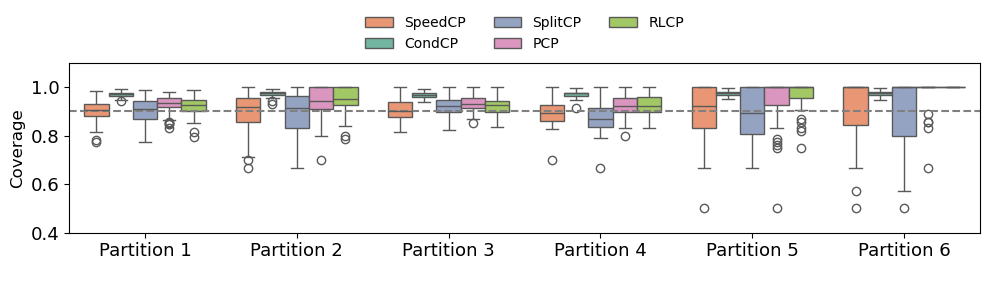

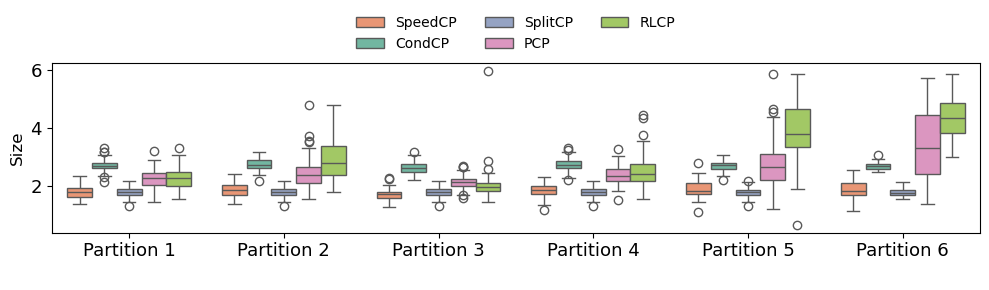

In [ ]:
method_names = list(METHODS.keys())
original_palette = sns.color_palette("Set2", n_colors=len(method_names))

reddest_index = max(range(len(original_palette)), key=lambda i: original_palette[i][0])

swapped_palette = original_palette.copy()
swapped_palette[0], swapped_palette[reddest_index] = swapped_palette[reddest_index], swapped_palette[0]
palette = dict(zip(method_names, swapped_palette))

# Create a dataframe for plotting coverage and cutoffs
coverage_data = []
for method in METHODS.keys():
    for c in range(1, K):
        cover_vals = cover_by_cluster[method][c-1]
        cutoff_vals = cut_by_cluster[method][c-1]
        for val in cover_vals:
            coverage_data.append({
                "method": method,
                "shift_type": f"Partition {c}",
                "type": "Coverage",
                "value": val
            })
        for val in cutoff_vals:
            coverage_data.append({
                "method": method,
                "shift_type": f"Partition {c}",
                "type": "Size",
                "value": val
            })
# Create a single plot
fig, ax = plt.subplots(figsize=(10, 3))

coverage_df = pd.DataFrame(coverage_data)
coverage_df["shift_type"] = coverage_df["shift_type"].astype(str)

# Create boxplot
sns.boxplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Partition') & (coverage_df['type'] == 'Coverage')], 
            x="shift_type", y="value", hue="method", 
            palette=palette, ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
ax.set_ylim(0.4, 1.1)
ax.axhline(0.9, color='gray', linestyle='--', label="target miscoverage")
ax.set_xlabel(" ")
ax.set_ylabel("Coverage", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Partition') & (coverage_df['type'] == 'Size')], 
            x="shift_type", y="value", hue="method", 
            palette=palette, ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
#ax.set_ylim(0.4, 1.1)
ax.set_xlabel(" ")
ax.set_ylabel("Size", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()

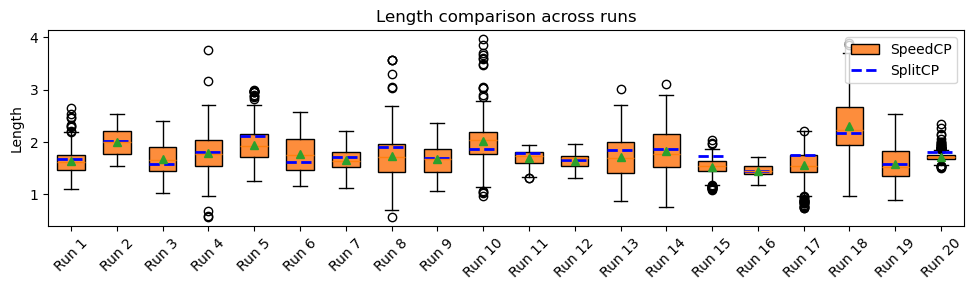

In [8]:
def boxplots_speedcp_vs_scp(runs, title=None, fname=None):
    """
    For each run, plot a boxplot of SpeedCP cutoffs and overlay the
    Split-CP cutoff as a horizontal line.
    - runs: list of dicts with keys:
        - "cutoffs_lakcp": array-like of cutoffs (per cluster or per point)
        - "cutoffs_scp":   scalar cutoff for that run
    """
    n_runs = len(runs)
    lakcp_data = []
    scp_lines = []

    for r in runs:
        lakcp = np.ravel(r["cutoffs_speedcp"])   # ensure 1D
        lakcp_data.append(lakcp)
        scp_lines.append(r["cutoffs_scp"])     # scalar per run

    plt.figure(figsize=(max(6, 0.5*n_runs), 3))

    # Boxplots of LAKCP cutoffs
    bp = plt.boxplot(lakcp_data, positions=np.arange(n_runs), widths=0.6,
                     patch_artist=True, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor("#fd8d3c")

    # Overlay SCP cutoffs as horizontal line segments per run
    for i, scp_val in enumerate(scp_lines):
        plt.hlines(scp_val, i-0.3, i+0.3, colors="blue", linestyles="--", lw=2)

    plt.xticks(np.arange(n_runs), [f"Run {i+1}" for i in range(n_runs)], rotation=45)
    plt.ylabel("Length")
    plt.title(title if title else "Per-run LAKCP cutoff distributions with SCP cutoff")
    legend_handles = [
        bp['boxes'][0],
        Line2D([0], [0], color="blue", linestyle="--", lw=2)
    ]
    plt.legend(legend_handles, ["SpeedCP", "SplitCP"], loc="upper right")

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=160)
    plt.show()
boxplots_speedcp_vs_scp(runs[:20], title="Length comparison across runs")